In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv('Sample - Superstore.csv',encoding='latin1')


In [30]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## Data Cleaning

In [3]:
#checking for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [4]:
df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Product ID','Ship Date', 'Ship Mode','Product Name','Product ID','Customer Name','Postal Code'], inplace=True)
df.head()

,Order Date,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,6/12/2016,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,10/11/2015,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,10/11/2015,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Data Preprocessing

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df.head()

,Order Date,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Day,Quarter
0,2016-11-08,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,11,8,4
1,2016-11-08,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,11,8,4
2,2016-06-12,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,6,12,2
3,2015-10-11,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,10,11,4
4,2015-10-11,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,10,11,4


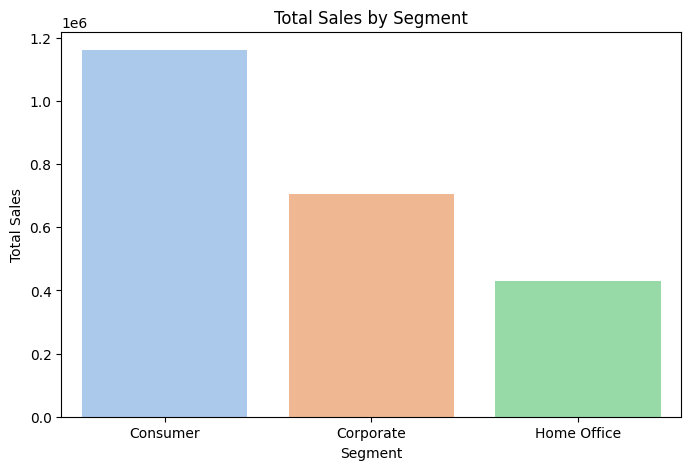

In [6]:
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_sales.reset_index(), x='Segment', y='Sales', palette='pastel',hue='Segment')
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()

#### Consumers are most customers to order.

## Sales Analysis

Text(0.5, 1.0, 'Yearly Sales Trend')

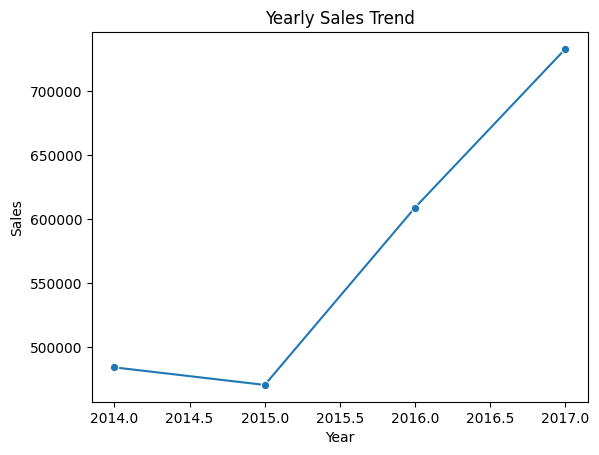

In [7]:
#yearly sales trend
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
sns.lineplot(data=yearly_sales, x='Year', y='Sales', marker='o')
plt.title('Yearly Sales Trend') 

#### The business is experiencing steady growth over time, indicating increasing customer demand and market expansion.

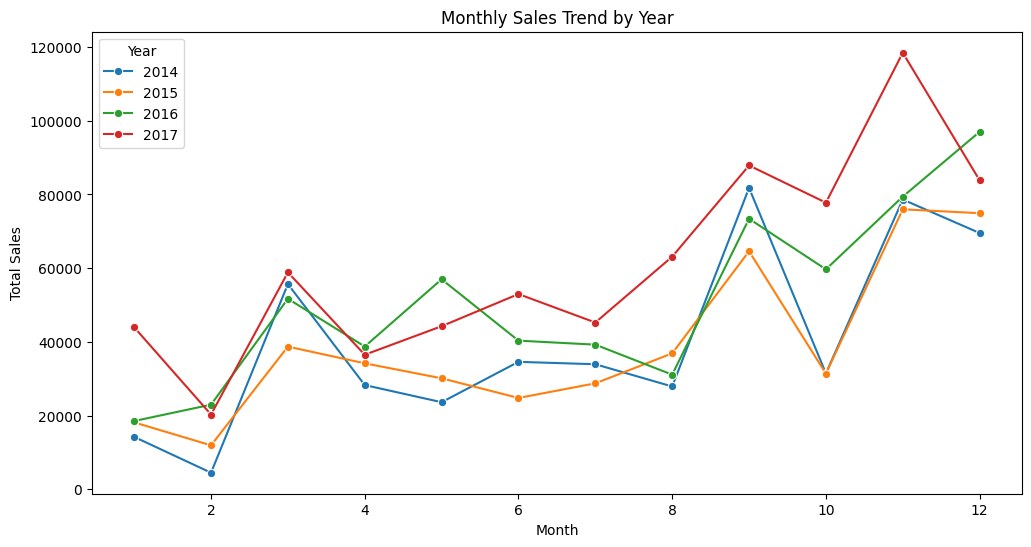

In [8]:
#Monthly sales trend year wise
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o', palette='tab10')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')   
plt.legend(title='Year')
plt.show()    

Text(0.5, 1.0, 'Quarterly Sales Trend by Year')

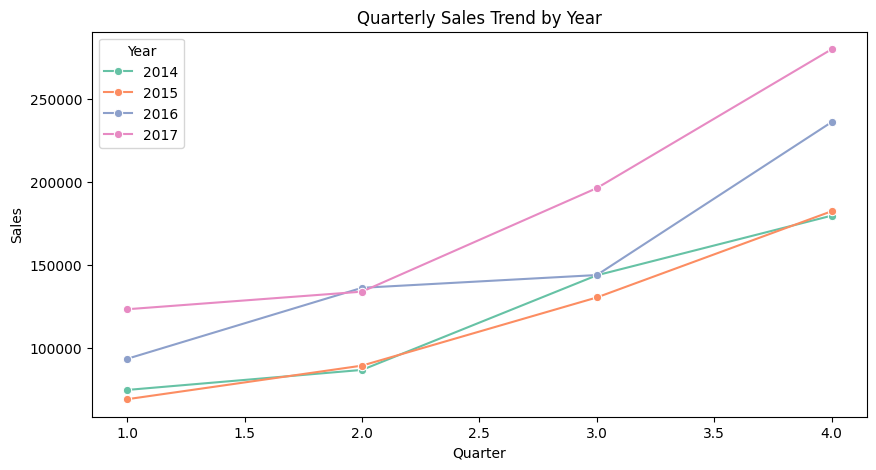

In [9]:
#quarterly sales trend
quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=quarterly_sales, x='Quarter', y='Sales', hue='Year', marker='o', palette='Set2')
plt.title('Quarterly Sales Trend by Year')

From Q2 to Q4 there is significant raise in sales.so there is seasonal sales trend.

Text(0.5, 1.0, 'Total Sales by Region')

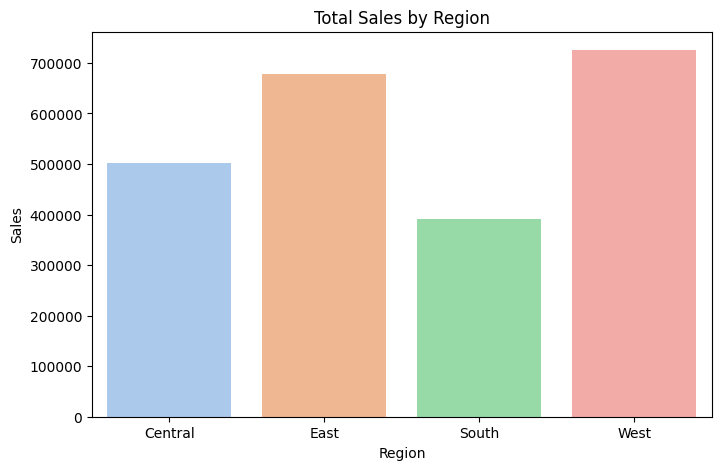

In [10]:
#Regional sales distribution
regional_sales = df.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=regional_sales, x='Region', y='Sales', palette='pastel',hue='Region')
plt.title('Total Sales by Region')

#### West region sales are higher while south region sales are low.

Text(0.5, 1.0, 'Total Sales by Category')

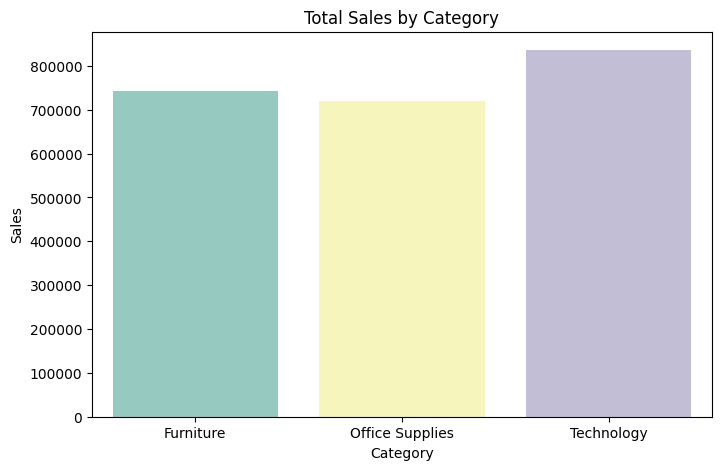

In [11]:
#category wise sales distribution
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Set3',hue='Category')
plt.title('Total Sales by Category')    

#### all categories sales are equally distributed.

## Data Preprocessing & Feature Engineering

In [12]:
#daily sales trends attribute engineering
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales['Order Date'] = pd.to_datetime(daily_sales['Order Date'])
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['Quarter'] = daily_sales['Order Date'].dt.quarter
daily_sales['Weekday'] = daily_sales['Order Date'].dt.weekday
daily_sales.head()

,Order Date,Sales,Year,Month,Day,Quarter,Weekday
0,2014-01-03,16.448,2014,1,3,1,4
1,2014-01-04,288.060,2014,1,4,1,5
2,2014-01-05,19.536,2014,1,5,1,6
3,2014-01-06,4407.100,2014,1,6,1,0
4,2014-01-07,87.158,2014,1,7,1,1


In [13]:
#creating lag features for daily sales
daily_sales['lag_1'] = daily_sales['Sales'].shift(1)
daily_sales['lag_7'] = daily_sales['Sales'].shift(7)
daily_sales['lag_30'] = daily_sales['Sales'].shift(30)
daily_sales.head()

,Order Date,Sales,Year,Month,Day,Quarter,Weekday,lag_1,lag_7,lag_30
0,2014-01-03,16.448,2014,1,3,1,4,NaN,NaN,NaN
1,2014-01-04,288.060,2014,1,4,1,5,16.448,NaN,NaN
2,2014-01-05,19.536,2014,1,5,1,6,288.060,NaN,NaN
3,2014-01-06,4407.100,2014,1,6,1,0,19.536,NaN,NaN
4,2014-01-07,87.158,2014,1,7,1,1,4407.100,NaN,NaN


In [14]:
#creating rolling features for sales
daily_sales['rolling_7'] = daily_sales['Sales'].rolling(window=7).mean()
daily_sales['rolling_30'] = daily_sales['Sales'].rolling(window=30).mean()
daily_sales.head()

,Order Date,Sales,Year,Month,Day,Quarter,Weekday,lag_1,lag_7,lag_30,rolling_7,rolling_30
0,2014-01-03,16.448,2014,1,3,1,4,NaN,NaN,NaN,NaN,NaN
1,2014-01-04,288.060,2014,1,4,1,5,16.448,NaN,NaN,NaN,NaN
2,2014-01-05,19.536,2014,1,5,1,6,288.060,NaN,NaN,NaN,NaN
3,2014-01-06,4407.100,2014,1,6,1,0,19.536,NaN,NaN,NaN,NaN
4,2014-01-07,87.158,2014,1,7,1,1,4407.100,NaN,NaN,NaN,NaN


In [15]:
daily_sales.dropna(inplace=True)
daily_sales.head()

,Order Date,Sales,Year,Month,Day,Quarter,Weekday,lag_1,lag_7,lag_30,rolling_7,rolling_30
30,2014-02-12,129.568,2014,2,12,1,2,2043.400,211.646,16.448,418.550857,594.361633
31,2014-02-14,576.726,2014,2,14,1,4,129.568,97.112,288.060,487.067143,603.983833
32,2014-02-15,21.360,2014,2,15,1,5,576.726,134.384,19.536,470.920857,604.044633
33,2014-02-16,9.040,2014,2,16,1,6,21.360,330.512,4407.100,424.996286,457.442633
34,2014-02-17,54.208,2014,2,17,1,0,9.040,180.320,87.158,406.980286,456.344300


#### Data Splitting

In [16]:
split_idx = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_idx]
test = daily_sales.iloc[split_idx:]

In [17]:
X_train = train.drop(columns=['Order Date', 'Sales'])
y_train = train['Sales']

X_test = test.drop(columns=['Order Date', 'Sales'])
y_test = test['Sales']

In [18]:
print(train['Order Date'].min())
print(train['Order Date'].max())

print(test['Order Date'].min())
print(test['Order Date'].max())

2014-02-12 00:00:00
2017-04-10 00:00:00
2017-04-11 00:00:00
2017-12-30 00:00:00


## Model Training

In [19]:
from  sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mse)
print(f'Mean Absolute Error: {mae_lr}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 1641.6110370346785
Mean Squared Error: 4927843.401256575
R^2 Score: 0.19514762366683858


In [21]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f'Random Forest - Mean Absolute Error: {mae_rf}')
print(f'Random Forest - Mean Squared Error: {mse_rf}')
print(f'Random Forest - R^2 Score: {r2_rf}')

Random Forest - Mean Absolute Error: 1705.9186935362109
Random Forest - Mean Squared Error: 5142488.580203943
Random Forest - R^2 Score: 0.16009016175557056


In [22]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
print(f'XGBoost - Mean Absolute Error: {mae_xgb}')
print(f'XGBoost - Mean Squared Error: {mse_xgb}')
print(f'XGBoost - R^2 Score: {r2_xgb}')

XGBoost - Mean Absolute Error: 1643.8196058972571
XGBoost - Mean Squared Error: 5242573.441250801
XGBoost - R^2 Score: 0.14374355093835234


#### Comparing Model Perfomances

In [23]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R^2 Score': [r2, r2_rf, r2_xgb]
})
comparison_df

,Model,MAE,RMSE,R^2 Score
0,Linear Regression,1641.611037,2219.874636,0.195148
1,Random Forest,1705.918694,2267.705576,0.160090
2,XGBoost,1643.819606,2289.666666,0.143744


#### Linear Regression is the Best Model.
#### the R^2 score is low that is because the noise in the sales data in real world.

Text(0.5, 1.0, 'Actual vs Predicted Sales (Linear Regression)')

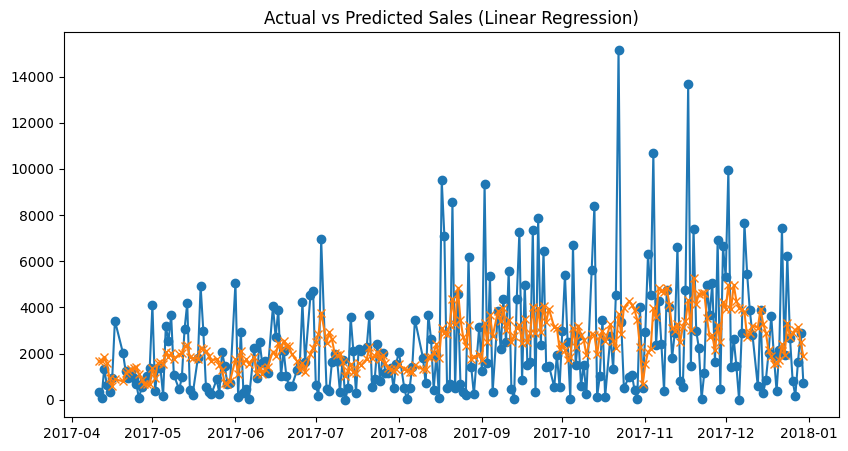

In [24]:
#graph between predicted and actual sales in linear regression
plt.figure(figsize=(10, 5))
plt.plot(test['Order Date'], y_test, label='Actual Sales', marker='o')
plt.plot(test['Order Date'], y_pred, label='Predicted Sales (Linear Regression)', marker='x')
plt.title('Actual vs Predicted Sales (Linear Regression)')

In [25]:
#next 30 days sales prediction using linear regression
last_date = daily_sales['Order Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
future_df = pd.DataFrame({'Order Date': future_dates})
future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['Quarter'] = future_df['Order Date'].dt.quarter
future_df['Weekday'] = future_df['Order Date'].dt.weekday
future_df['lag_1'] = daily_sales['Sales'].iloc[-1]
future_df['lag_7'] = daily_sales['Sales'].iloc[-7]
future_df['lag_30'] = daily_sales['Sales'].iloc[-30]
future_df['rolling_7'] = daily_sales['Sales'].iloc[-7:].mean()
future_df['rolling_30'] = daily_sales['Sales'].iloc[-30:].mean()
X_future = future_df.drop(columns=['Order Date'])
future_df['Predicted Sales'] = lr.predict(X_future)



In [26]:
#saving the model
import joblib
joblib.dump(lr, 'linear_regression_sales_model.pkl')

['linear_regression_sales_model.pkl']

In [27]:
#dowloading future predictions
future_df.to_csv('future_sales_predictions.csv', index=False)

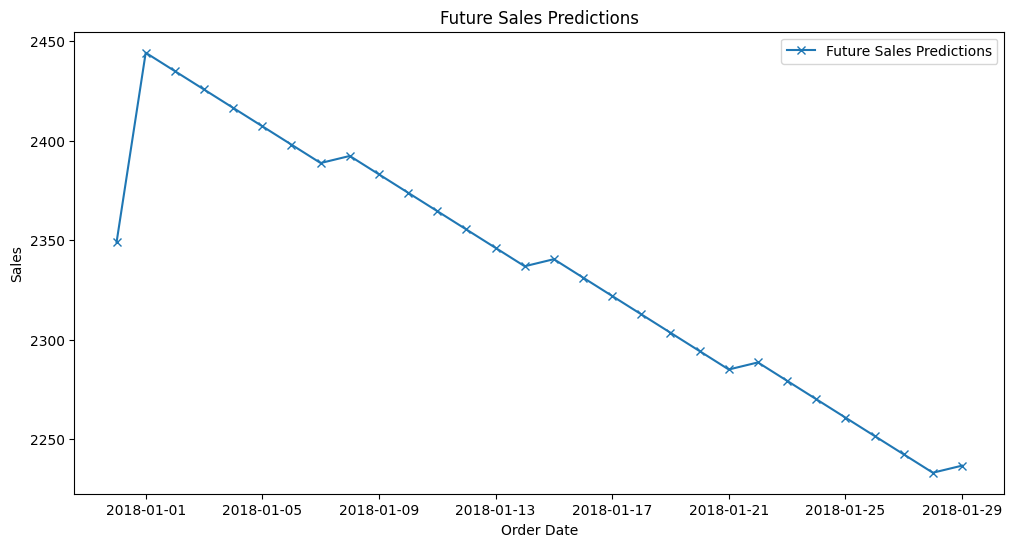

In [28]:
#30 days sales prediction visualization(only future predictions)
plt.figure(figsize=(12, 6))
plt.plot(future_df['Order Date'], future_df['Predicted Sales'], label='Future Sales Predictions', marker='x')
plt.title('Future Sales Predictions')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.legend()
